# Temporal Comparison — Summary
RMSD bar chart grouped by joint and model pair.
Edit the **CONFIGURATION** cell paths before running.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import argrelmin
import ezc3d

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  ← edit paths here
# ══════════════════════════════════════════════════════════════════════════════

# -- Anatomical landmark scenario ----------------------------------------------
# Identifies which anatomical distances were used to build the virtual markers.
# Appears as a prefix in all plot titles.
# Option 1: "(PX -> T8) + (C7 -> T8) Distances"
# Option 2: "(IJ -> T8) + (C7 -> T8) Distances"
# Option 3: "(PX -> T8) + (IJ -> T8) + (C7 -> T8) Distances"
SCENARIO_NAME = "(PX -> T8) + (C7 -> T8) Distances"

# Each joint entry: display name, variable name, Euler component, and 3 C3D
# paths for [Complete, With C7, Without C7] — for ONE side only (e.g. Left).
# Repeat for Right if needed by duplicating entries with different paths.

JOINTS = [
    {
        "name":      "Shoulder Flex/Ext",
        "variable":  "Humerothoracic_ZXY_Op1",
        "component": 0,
        "side":      "Left",
        "paths": [
            r"C:\Projects\data_organized\grab 7_c3d\standing\Original\Shoulder_Flex_Ext_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\C7\PX_C7\Shoulder_Flex_Ext_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\NOT_C7\PX_C7\Shoulder_Flex_Ext_Left_Cont01.c3d",
        ],
    },
    {
        "name":      "Shoulder Abd/Add",
        "variable":  "Humerothoracic_XZY_Op1",
        "component": 0,
        "side":      "Left",
        "paths": [
            r"C:\Projects\data_organized\grab 7_c3d\standing\Original\Shoulder_Abd_Add_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\C7\PX_C7\Shoulder_Abd_Add_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\NOT_C7\PX_C7\Shoulder_Abd_Add_Left_Cont01.c3d",
        ],
    },
    {
        "name":      "Shoulder Int/Ext Rot",
        "variable":  "Humerothoracic_XZY_Op2",
        "component": 2,
        "side":      "Left",
        "paths": [
            r"C:\Projects\data_organized\grab 7_c3d\standing\Original\Shoulder_Rotac_Int_Ext_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\C7\PX_C7\Shoulder_Rotac_Int_Ext_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\NOT_C7\PX_C7\Shoulder_Rotac_Int_Ext_Left_Cont01.c3d",
        ],
    },
    {
        "name":      "Elbow Flex/Ext",
        "variable":  "Elbow_Op1",
        "component": 0,
        "side":      "Left",
        "paths": [
            r"C:\Projects\data_organized\grab 7_c3d\standing\Original\Elbow_Flex_Ext_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\C7\PX_C7\Elbow_Flex_Ext_Left_Cont01.c3d",
            r"C:\Projects\data_organized\grab 7_c3d\standing\NOT_C7\PX_C7\Elbow_Flex_Ext_Left_Cont01.c3d",
        ],
    },
]

# Bilateral trunk inclination recording — one set of 3 C3D paths (no Left/Right
# split). Both "Thorax Lateral Inclination" and "Trunk Extended Lateral
# Inclination" are derived from each of these files via compute_thorax_trunk_pair().
INCLINATION_RECORDINGS = [
    r"C:\Projects\data_organized\grab 7_c3d\standing\Original\Trunk_Inclination_Bi_Cont01.c3d",
    r"C:\Projects\data_organized\grab 7_c3d\standing\C7\PX_C7\Trunk_Inclination_Bi_Cont01.c3d",
    r"C:\Projects\data_organized\grab 7_c3d\standing\NOT_C7\PX_C7\Trunk_Inclination_Bi_Cont01.c3d",
]
ZERO_THRESHOLD = 15.0   # degrees — sign-recovery threshold for Thorax Lateral Inclination

PAIR_LABELS = ["Complete − With C7", "Complete − Without C7", "With C7 − Without C7"]
PAIR_COLORS = ["#2E86C1", "#27AE60", "#E67E22"]

In [3]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def read_c3d(filepath):
    filepath = os.path.normpath(os.path.abspath(filepath))
    c = ezc3d.c3d(filepath)
    raw_labels = c["parameters"]["POINT"]["LABELS"]["value"]
    point_data = c["data"]["points"]
    n_labels   = min(len(raw_labels), point_data.shape[1])
    try:
        rate_val   = c["parameters"]["POINT"]["RATE"]["value"]
        frame_rate = int(float(rate_val[0]) if hasattr(rate_val, "__len__") else float(rate_val))
    except Exception:
        frame_rate = int(c["header"]["frame_rate"])
    clean_labels = [
        lbl.split(":")[-1].strip() if ":" in lbl else lbl.strip()
        for lbl in raw_labels[:n_labels]
    ]
    model_outputs = {lbl: point_data[:3, i, :].copy() for i, lbl in enumerate(clean_labels)}
    return {"frame_rate": frame_rate, "model_outputs": model_outputs}


def extract_signal(path, variable, component, side):
    c3d   = read_c3d(path)
    label = variable if side == "—" else side + variable
    return c3d["model_outputs"][label][component, :].astype(float)


def compute_thorax_trunk_pair(c3d_path, zero_threshold=15.0):
    """
    Computes both lateral inclination signals from a single C3D file.

    Thorax Lateral Inclination:
      norm = sqrt(ThoraxAngles[X]^2 + ThoraxAngles[Y]^2)
      Sign recovered segment-by-segment using the median of trunk_z.

    Trunk Extended Lateral Inclination:
      trunk_z = Trunk_Inclination_Angle[Z] - 90.0  (hardware offset correction)

    Returns: (thorax_signed, trunk_z, frame_rate) — all 1-D float arrays.
    """
    c3d = read_c3d(c3d_path)
    mo  = c3d["model_outputs"]
    fr  = c3d["frame_rate"]

    thorax_key = next(
        (k for k in mo if "THORAXANGLES" in k.replace(" ", "_").upper()), None
    )
    trunk_key = next(
        (k for k in mo if "TRUNK_INCLINATION_ANGLE" in k.replace(" ", "_").upper()), None
    )
    if thorax_key is None:
        raise KeyError(f"ThoraxAngles not found in {os.path.basename(c3d_path)}.\nAvailable: {list(mo.keys())}")
    if trunk_key is None:
        raise KeyError(f"Trunk_Inclination_Angle not found in {os.path.basename(c3d_path)}.\nAvailable: {list(mo.keys())}")

    trunk_z = mo[trunk_key][2, :].astype(float) - 90.0

    x    = mo[thorax_key][0, :].astype(float)
    y    = mo[thorax_key][1, :].astype(float)
    norm = np.sqrt(x**2 + y**2)

    minima_idx  = argrelmin(norm, order=5)[0]
    flip_points = minima_idx[norm[minima_idx] <= zero_threshold]

    n = len(norm)
    sign_arr   = np.ones(n)
    boundaries = np.concatenate([[0], flip_points, [n]]).astype(int)
    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i + 1]
        sign_arr[start:end] = 1.0 if np.median(trunk_z[start:end]) >= 0.0 else -1.0

    thorax_signed = norm * sign_arr
    return thorax_signed, trunk_z, fr


def rmsd(a, b):
    """RMSD ignoring frames where either signal has an invalid (NaN) value."""
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    valid = ~(np.isnan(a) | np.isnan(b))
    if not valid.any():
        return float("nan"), 0.0
    diff = a[valid] - b[valid]
    pct_valid = 100 * valid.mean()
    return float(np.sqrt(np.mean(diff**2))), pct_valid

In [4]:
# ── Compute RMSD for every joint × pair ──────────────────────────────────────

results = []   # list of (joint_name, [rmsd_c7, rmsd_no_c7, rmsd_c7_no_c7])

for j in JOINTS:
    sig_complete  = extract_signal(j["paths"][0], j["variable"], j["component"], j["side"])
    sig_c7        = extract_signal(j["paths"][1], j["variable"], j["component"], j["side"])
    sig_no_c7     = extract_signal(j["paths"][2], j["variable"], j["component"], j["side"])

    r_c7,       pct_c7       = rmsd(sig_complete, sig_c7)
    r_no_c7,    pct_no_c7    = rmsd(sig_complete, sig_no_c7)
    r_c7_no_c7, pct_c7_no_c7 = rmsd(sig_c7, sig_no_c7)

    results.append((j["name"], [r_c7, r_no_c7, r_c7_no_c7]))
    print(f"{j['name']:25s}  RMSD: {r_c7:.2f} ({pct_c7:.1f}% valid) / "
          f"{r_no_c7:.2f} ({pct_no_c7:.1f}% valid) / "
          f"{r_c7_no_c7:.2f} ({pct_c7_no_c7:.1f}% valid) °")

Shoulder Flex/Ext          RMSD: 1.99 (100.0% valid) / 3.62 (100.0% valid) / 2.46 (100.0% valid) °
Shoulder Abd/Add           RMSD: 1.76 (100.0% valid) / 1.05 (100.0% valid) / 2.09 (100.0% valid) °
Shoulder Int/Ext Rot       RMSD: 2.17 (99.9% valid) / 5.33 (99.9% valid) / 7.16 (99.9% valid) °
Elbow Flex/Ext             RMSD: 0.00 (100.0% valid) / 0.00 (100.0% valid) / 0.00 (100.0% valid) °


In [5]:
# ── Compute RMSD for Thorax & Trunk Lateral Inclination (bilateral) ──────────

thorax_sigs = []
trunk_sigs  = []
for path in INCLINATION_RECORDINGS:
    thorax, trunk, _ = compute_thorax_trunk_pair(path, ZERO_THRESHOLD)
    thorax_sigs.append(thorax)
    trunk_sigs.append(trunk)

for angle_name, sigs in [("Thorax Lateral Inclination", thorax_sigs),
                          ("Trunk Extended Lateral Inclination", trunk_sigs)]:
    sig_complete, sig_c7, sig_no_c7 = sigs

    r_c7,       pct_c7       = rmsd(sig_complete, sig_c7)
    r_no_c7,    pct_no_c7    = rmsd(sig_complete, sig_no_c7)
    r_c7_no_c7, pct_c7_no_c7 = rmsd(sig_c7, sig_no_c7)

    results.append((angle_name, [r_c7, r_no_c7, r_c7_no_c7]))
    print(f"{angle_name:25s}  RMSD: {r_c7:.2f} ({pct_c7:.1f}% valid) / "
          f"{r_no_c7:.2f} ({pct_no_c7:.1f}% valid) / "
          f"{r_c7_no_c7:.2f} ({pct_c7_no_c7:.1f}% valid) °")

Thorax Lateral Inclination  RMSD: 2.08 (100.0% valid) / 3.60 (100.0% valid) / 2.44 (100.0% valid) °
Trunk Extended Lateral Inclination  RMSD: 0.34 (100.0% valid) / 0.53 (100.0% valid) / 0.40 (100.0% valid) °


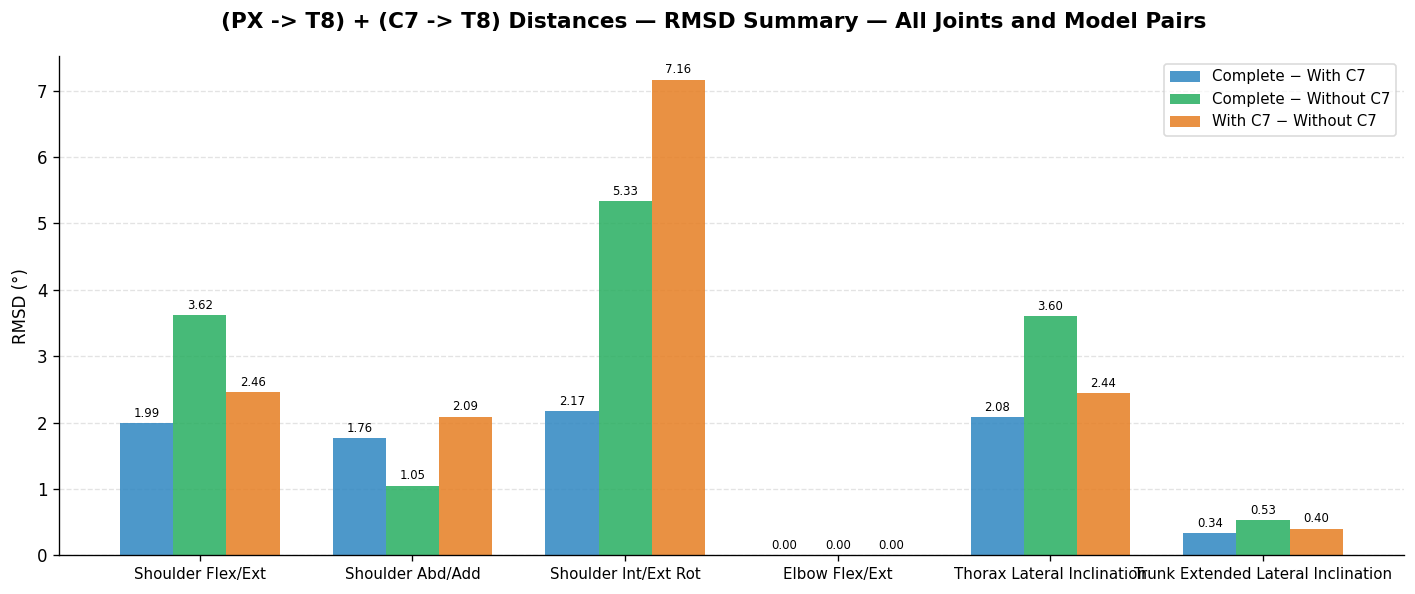

In [6]:
# ── RMSD bar chart grouped by joint ──────────────────────────────────────────

n_joints = len(results)
n_pairs  = 3
x        = np.arange(n_joints)
width    = 0.25
offsets  = [-width, 0, width]

fig, ax = plt.subplots(figsize=(max(8, n_joints * 2), 5))
fig.suptitle(f"{SCENARIO_NAME} — RMSD Summary — All Joints and Model Pairs", fontsize=13, fontweight="bold")

for p_idx, (label, color, offset) in enumerate(zip(PAIR_LABELS, PAIR_COLORS, offsets)):
    values = [results[j][1][p_idx] for j in range(n_joints)]
    bars   = ax.bar(x + offset, values, width, color=color, alpha=0.85, label=label)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in results], fontsize=9)
ax.set_ylabel("RMSD (°)", fontsize=10)
ax.legend(fontsize=9, framealpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()